# Viewing and manipulating FITS images
## Authors
Lia Corrales, Kris Stern, Stephanie T. Douglas, Kelle Cruz, Lúthien Liu, Zihao Chen, Saima Siddiqui

## Learning Goals
Open FITS files and load image data

Make a 2D histogram with image data

Stack several images into a single image

Write image data to a FITS file

## Companion Content
This link provides a comprehensive description of FITS file usage in this tutorial:
https://docs.astropy.org/en/stable/io/fits/index.html

# Summary
This tutorial demonstrates the use of astropy.utils.data to download a data file, then uses astropy.io.fits to open the file, and lastly uses matplotlib to view the image with different color scales and stretches and to make histograms. In this tutorial we’ve also included a demonstration of simple image stacking.

In [4]:
import numpy as np

# Set up matplotlib
import matplotlib.pyplot as plt

%matplotlib inline 
# ^^^ this is a "magic command" (I guess that's what they call it) that renders the plot directly in the output cell.

from astropy.io import fits

Download the example FITS files (which contain the image data for the Horsehead Nebula) for this tutorial.

First, we need to download the FITS file image for this tutorial. This is an astronomical image of the Horsehead Nebula taken with a photographic plate. The image has been digitized, that is, the image has been scanned by a computer and converted to a 2-D array. Each position in the array corresponds with the projected position on the sky, and bright areas of the image have high values and dark areas have low values in the array.

Images taken with astronomical instruments called CCDs or “charge-coupled devices” are organized similarly. When illuminated by light, CCDs accumulate electrons, converting brightness values to electron counts. A CCD image is essentially a 2-D array, where each position on the array represents a single CCD pixel, and the values in that array represent the number of counts registered in that pixel.



In [5]:
from astropy.utils.data import download_file

# downloads HorseHead.fits and sets it to "image_file"
image_file = download_file(
    "http://data.astropy.org/tutorials/FITS-images/HorseHead.fits", cache=True
)

To use your own data in the future, use astropy.io.fits.open()

# Opening FITS files and loading the image data

In [7]:
# Opening the fits file
hdu_list = fits.open(image_file)
hdu_list.info()

Filename: /Users/alexleesman/.astropy/cache/download/url/ff6e0b93871033c68022ca026a956d87/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


Generally, the image information is located in the PRIMARY block. The blocks are numbered and can be accessed by indexing hdu_list.

In [8]:
image_data = hdu_list[0].data

Our data is now stored as a 2D numpy array. But how do we know the dimensions of the image? We can look at the shape of the array. The numbers represent pixel intensity.

In [10]:
print(type(image_data)) # prints what image_data is; in this case it is a numpy array
print(image_data.shape) # prints the dimensions of image_data

<class 'numpy.ndarray'>
(893, 891)


Great! At this point, we can close the FITS file because we’ve stored everything we wanted to a variable. By closing the FITS file, we can make sure that it won’t continue using up excess memory or file handles on the computer.

In [11]:
hdu_list.close() # closes the fits file

## Shortcut
You can bypass the previous steps by calling fits.getdata if you don't need to examine the fits header.

In [12]:
image_data = fits.getdata(image_file)

Note that the image data is held in a 2-D numpy array. We can also see the number of pixels in the image by printing the 2-D array shape. This shows us that the image is 893 x 891 pixels.

In [13]:
print(type(image_data))  # Show the Python type for image_data
print(image_data.shape)  # Show the number of pixels per side in the 2-D image

<class 'numpy.ndarray'>
(893, 891)


# Viewing the image data and getting basic statistics

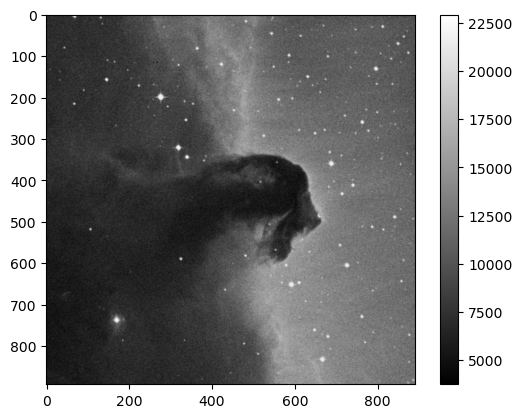

In [14]:
plt.imshow(image_data, cmap = "gray")
plt.colorbar()

# To see more color maps
# http://wiki.scipy.org/Cookbook/Matplotlib/Show_colormaps

For basic statistics about the image:

In [17]:
print("Min:", np.min(image_data)) # lowest value; translates to the lowest-intensity pixel or the dimmest spot
print("Max:", np.max(image_data)) # highest value; translates to the highest-intensity pixel or the brightest spot
print("Mean:", np.mean(image_data))
print("Stdev:", np.std(image_data))

# Dark spots are dim, light spots are luminous.

Min: 3759
Max: 22918
Mean: 9831.481676287574
Stdev: 3032.3927542049046


# Plotting a Histogram

Histograms can be plotted by matplotlib.pyplot.hist(). However, since the image is a 2D numpy array, it needs to be converted into one dimension. This can be done by ndarray.flatten() from numpy, which will return a 1D numpy array. You can use print statements to check if it is still a numpy array, and that the number of entries equals the number of pixels. 

In [18]:
print(893*891) # The image is 891 x 893 pixels; this prints the total number of pixels in an image of this dimension.
print(type(image_data.flatten())) # Checks what image_data flattened to 1D is; it is still a numpy array.
print(image_data.flatten().shape) # Finds the shape , i.e., number of entries in image_data flattened to 1D; it should be equal to the number of pixels.

795663
<class 'numpy.ndarray'>
(795663,)


Now make a plot with matplotlib.pyplot.hist

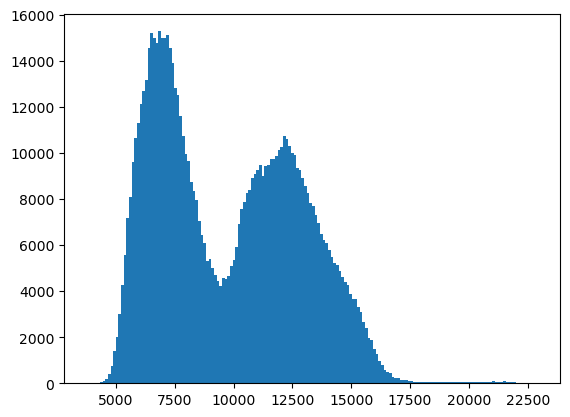

In [28]:
# Plots the histogram of image_data flattened to 1D.

# image_data.flatten() is the array of image_data flattened to 1D being plotted.

# Bins is the number of bins (segments); "auto" chooses the number of bins for you.
# It can also be set to an int equalling the number of bins or a list of values of where the edges are.

histogram = plt.hist(image_data.flatten(), bins="auto")

# x-axis is the intensity of the pixels; brightness of the pixel increases with x.
# y-axis is the number of pixels at intensity x.

# Displaying The Image With a Logarithmic Scale

To use a logarithmic color scale, load the LogNorm object from matplotlib.

In [29]:
from matplotlib.colors import LogNorm

[Text(1, 5000.0, '5,000'),
 Text(1, 10000.0, '10,000'),
 Text(1, 20000.0, '20,000')]

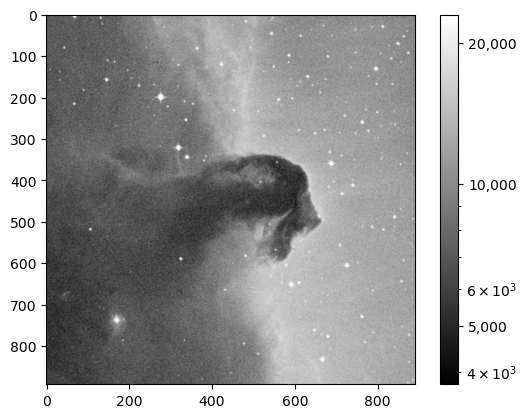

In [47]:
plt.imshow(image_data, cmap='gray', norm=LogNorm()) # shows image_data image with logarithmic color scale
# Normalization: process that changes the pixel intensity values
# If this log norm'ed data was plotted in a histogram, it would sort the darker pixels into more bins and compress the lighter pixels fewer bins (I think?)
# The result is much greater contrast in the darker regions while only increasing contrast in the lighter regions slightly.

#plt.colorbar()
# See the code with the added ticks below first
# When ran without the added ticks, the color bar tick labels are 4*10**3, 6*10**3, 10**4, and 2*10**4. 
# Those values are approx. the lowest x, absolute maximum y, local minimum y, and highest x of the histogram. Are they chosen automatically based on the data?


# Chose the ticks based on the histogram above
cbar = plt.colorbar(ticks=[5.0e3, 1.0e4, 2.0e4])  # sets ticks on the color bar at 5000, 10000, and 20000. These ticks are approx. the peak and trough of the histogram. 

cbar.ax.set_yticklabels(["5,000","10,000","20,000"]) # sets tick labels for the color bar at 5000, 10000, 20000 as the strings in the array

Notice how the image looks brighter, and some details in the bottom left corner are now more visible.

# Basic Image Math: Image Stacking

You can perform math on the image like you can with any numpy array. We will stack several images of M13 (Hercules Globular Cluster) taken with a ~10" telescope.

Start by opening a series of FITS files and store the data in a list, named image_concat

In [64]:
base_url = "http://data.astropy.org/tutorials/FITS-images/M13_blue_{0:04d}.fits"

image_list = [download_file(base_url.format(n), cache=True) for n in range(1, 5 + 1)] # opens series of fits files from base_url
image_concat = [fits.getdata(image) for image in image_list] # stores the data from the series of fits in a list

# image_concat is a list of arrays.

You can stack the images by summing the concatenated list.

"Concatenate" means to link together in series. As previously stated, you are stacking images.

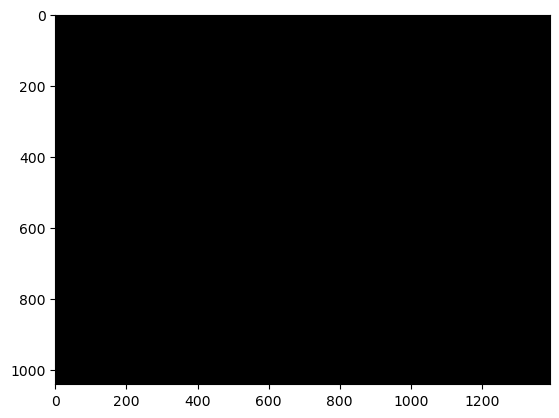

In [66]:
# The long way
final_image = np.zeros(shape=image_concat[0].shape) # initializes numpy array of all 0s; it has the dimensions of image_concat
plt.imshow(final_image, cmap="gray") # plots intialized array; should be all dark

# Stacks by summing the pixel values of the arrays that make up image_concat.
for image in image_concat:
    final_image += image

# The short way
# final_image = np.sum(image_concat, axis=0)

Now we need to decide on the best stretch. First, plot a histogram of the data.

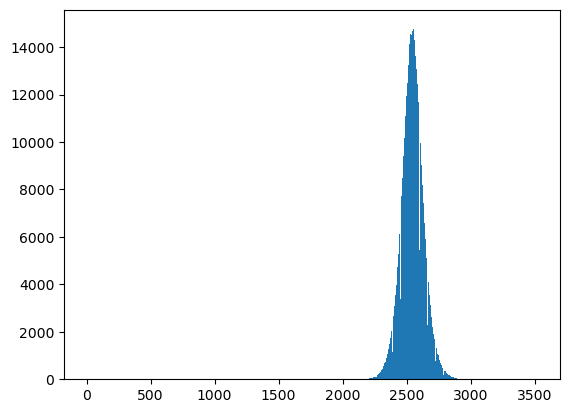

In [69]:
# flattens final_image to 1D and plots its histogram (frequency over intensity).
image_hist = plt.hist(final_image.flatten(), bins="auto")

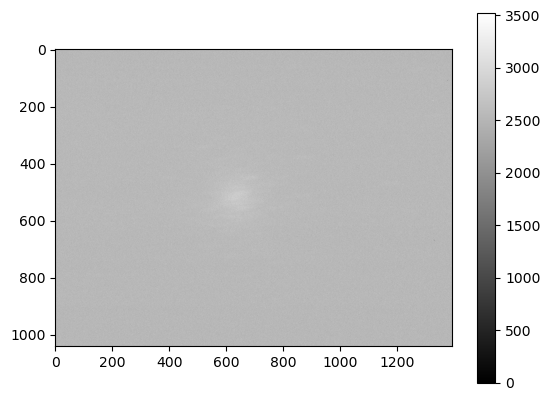

In [72]:
plt.imshow(final_image, cmap="gray")
plt.colorbar()

Keywords vmin and vmax will be used to set limits on the color scaling for imshow. By setting limits according to the histogram, the image will be generated with a more distinct color distribution.

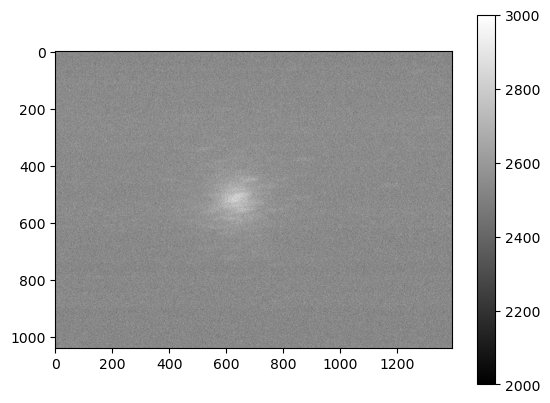

In [76]:
plt.imshow(final_image, cmap="gray", vmin=2e3, vmax=3e3) # plots final_image with intensity constraints vmin, vmax
plt.colorbar()

# vmin, vmax should be used when there is no explicit norm.

# Writing Image Data to a FITS File

We can do this using the writeto() method. 

You will recieve an error if the image you are trying to write already exists. That's why we've set overwrite = True

I don't know if I missed it in the reading, but I believe HDU stands for "Header Data Unit."

In [134]:
outfile = "Stacked_M13_blue.fits"

hdu = fits.PrimaryHDU(final_image)
#hdu.writeto(outfile) # returns an error since there already is stuff in the PrimaryHDU of Stacked_M13_blue; this prevents accidental deletion of data
hdu.writeto(outfile, overwrite=True) # overwrites PrimaryHDU of Stacked_M13_blue to the data of final_image

# Exercises
1. Determine the mean, median, and standard deviation of the stacked M13 image data. Add corresponding keywords ‘MEAN’, ‘MEDIAN’, and ‘STANDARD DEVIATION’ to the primary HDU in the output file you just wrote to, and store the statistics you calculated in keywords created in the header. See the Editing a FITS Header tutorial (https://learn.astropy.org/tutorials/FITS-header.html) to learn how to add the keywords.

2. Show the image of the Horsehead Nebula, but in units of surface brightness (magnitudes per square arcsecond). (Hint: the physical size of the image is 15x15 arcminutes.) For the Horsehead Nebula image used in this tutorial, assume that the magnitude is just the value stored in each pixel.

3. Now write out the image you just created, preserving the header the original image had, but add a keyword ‘UNITS’ with the value ‘mag per sq arcsec’. (Hint: it may be helpful to read the astropy.io.fits (https://docs.astropy.org/en/stable/io/fits/index.html) documentation if you’re not sure how to include both the header and the data.)

## 1.

### First, find the mean, median, and standard deviation of the stacked M13 data.

In [136]:
# Stacked M13 image data is final_image. To find the mean, median, and standard deviation, use the data flattened to 1D.
data_mean = np.mean(final_image.flatten())
data_median = np.median(final_image.flatten())
data_stddev = np.std(final_image.flatten())

print("Mean: ", data_mean, " Median: ", data_median, " Standard Deviation: ", data_stddev)

Mean:  2544.96438232206  Median:  2545.0  Standard Deviation:  87.90889022462106


### Next, add the keywords into the primary HDU in Stacked_M13_blue.fits and store the values for mean, median, and standard deviation.

In [137]:
# outfile = "Stacked_M13_blue.fits"
# Opens outfile, gets its info, and shows headers.
outfile_hdu_list = fits.open(outfile)
outfile_hdu_list.info()
outfile_hdu_list[0].header

Filename: Stacked_M13_blue.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (1392, 1040)   float64   


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1392                                                  
NAXIS2  =                 1040                                                  
EXTEND  =                    T                                                  

In [138]:
# "Since the primary HDU of a FITS file must contain image data, the data is now stored in a numpy array."
# "The header is stored in an object that acts like a standard Python dictionary."
# Primary HDU is indexed as [0].
with fits.open(outfile, mode='update') as outfile_hdu:
    outfile_hdu[0].header['MEAN'] = data_mean
    outfile_hdu[0].header['MEDIAN'] = data_median
    outfile_hdu[0].header['STD_DEV'] = data_stddev

# Check for changes to primary HDU
outfile_hdu_list = fits.open(outfile)
outfile_hdu_list.info()
outfile_hdu_list[0].header

Filename: Stacked_M13_blue.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   (1392, 1040)   float64   


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1392                                                  
NAXIS2  =                 1040                                                  
EXTEND  =                    T                                                  
MEAN    =     2544.96438232206                                                  
MEDIAN  =               2545.0                                                  
STD_DEV =    87.90889022462106                                                  

In [139]:
# Closes outfile
outfile_hdu_list.close()